# Inverse Design: TE0-to-TE1 Mode Converter on 400nm SiN

Design a compact mode converter that converts the fundamental TE0 mode to the first-order TE1 mode on a 400nm silicon nitride platform. This is the device presented in our CLEO 2026 paper.

**Device specs:**
- 400nm SiN core, SiO2 cladding, 1550nm
- 14 x 6 um freeform design region
- 2um input waveguide (TE0), 2um output waveguide (TE1)
- 120nm minimum feature size (R=8 density filter)
- Target: >90% mode conversion (-0.46 dB)

## Step 1: Environment Setup

In [1]:
%pip install -q hyperwave-community


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import hyperwave_community as hwc

hwc.set_device('auto')
hwc.set_verbose(True)

## Step 2: Device Configuration

In [3]:
# Materials
n_sin = 2.0
n_sio2 = 1.44
eps_sin = n_sin**2
eps_sio2 = n_sio2**2

# Wavelength and grid
wavelength = 1.55      # um
voxel_size = 0.030     # 30nm FDTD voxel
pixel_size = 0.015     # 15nm theta pixel (2x oversampled)

# Waveguide geometry
wg_height_um = 0.400   # 400nm SiN
wg_width_um = 2.0      # 2um input and output WGs
clad_um = 2.5          # SiO2 cladding top and bottom

# Design region
design_len_um = 14.0
design_wid_um = 6.0
wg_ext_um = 7.0        # waveguide extension on each side
y_pad_um = 2.5         # padding above/below design region

# Density filter: R=8 -> 120nm min feature
density_radius = max(1, int(round(0.120 / pixel_size)))
print(f'Density filter R={density_radius} ({density_radius * pixel_size * 1000:.0f}nm min feature)')

Density filter R=8 (120nm min feature)


## Step 3: Grid and Theta Initialization

In [4]:
# Grid dimensions in theta pixels (must be even)
wg_ext_t = (int(wg_ext_um / pixel_size) // 2) * 2
design_len_t = (int(design_len_um / pixel_size) // 2) * 2
design_wid_t = (int(design_wid_um / pixel_size) // 2) * 2
y_pad_t = (int(y_pad_um / pixel_size) // 2) * 2
input_wg_t = (int(wg_width_um / pixel_size) // 2) * 2
output_wg_t = input_wg_t

nx = wg_ext_t + design_len_t + wg_ext_t
ny = y_pad_t + design_wid_t + y_pad_t
yc = ny // 2

# Permittivity grid (half theta grid)
Lx = nx // 2
Ly = ny // 2

# Vertical stack in voxels
clad_px = int(round(clad_um / voxel_size))
wg_px = int(round(wg_height_um / voxel_size))
Lz = clad_px + wg_px + clad_px
z_sin_start = clad_px
z_sin_end = clad_px + wg_px
z_mid = clad_px + wg_px // 2

print(f'Theta grid: {nx} x {ny} @ {pixel_size*1000:.0f}nm')
print(f'Perm grid:  {Lx} x {Ly} x {Lz} @ {voxel_size*1000:.0f}nm')
print(f'SiN layer: z={z_sin_start} to {z_sin_end} ({wg_px} voxels = {wg_px*voxel_size*1000:.0f}nm)')
print(f'Design region: {design_len_t} x {design_wid_t} theta px = {design_len_um} x {design_wid_um} um')

Theta grid: 1864 x 732 @ 15nm
Perm grid:  932 x 366 x 179 @ 30nm
SiN layer: z=83 to 96 (13 voxels = 390nm)
Design region: 932 x 400 theta px = 14.0 x 6.0 um


## Step 4: Initialize Theta

The TE0-to-TE1 conversion requires breaking the y-symmetry of the design. Without an asymmetric initialization, the optimizer gets stuck in a symmetric local minimum with 0% conversion. We use a slight y-tilt across the design region.

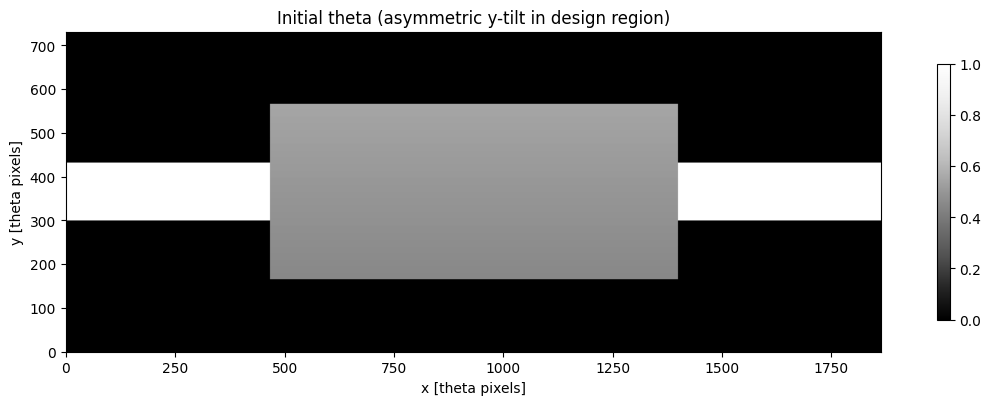

In [5]:
# Design region bounds in theta coords
dx0t = wg_ext_t
dx1t = wg_ext_t + design_len_t
dy0t = y_pad_t
dy1t = y_pad_t + design_wid_t

# Waveguide masks
in_y0 = yc - input_wg_t // 2
in_y1 = yc + input_wg_t // 2
out_y0 = yc - output_wg_t // 2
out_y1 = yc + output_wg_t // 2

in_wg_mask = np.zeros((nx, ny), dtype=bool)
in_wg_mask[:dx0t, in_y0:in_y1] = True
out_wg_mask = np.zeros((nx, ny), dtype=bool)
out_wg_mask[dx1t:, out_y0:out_y1] = True
waveguide_mask = in_wg_mask | out_wg_mask

# Theta: 0.5 in design region with asymmetric y-tilt
theta = np.zeros((nx, ny), dtype=np.float32)
theta[dx0t:dx1t, dy0t:dy1t] = 0.5
y_indices = np.arange(design_wid_t)
y_tilt = 0.10 * (y_indices / max(design_wid_t - 1, 1) - 0.5)
theta[dx0t:dx1t, dy0t:dy1t] += y_tilt[None, :]
theta = np.clip(theta, 0.0, 1.0)
theta[waveguide_mask] = 1.0

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(theta.T, origin='lower', cmap='Greys_r', vmin=0, vmax=1)
ax.set_title('Initial theta (asymmetric y-tilt in design region)')
ax.set_xlabel('x [theta pixels]')
ax.set_ylabel('y [theta pixels]')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Step 5: Density Filter and Layer Stack

Density: (1864, 732)


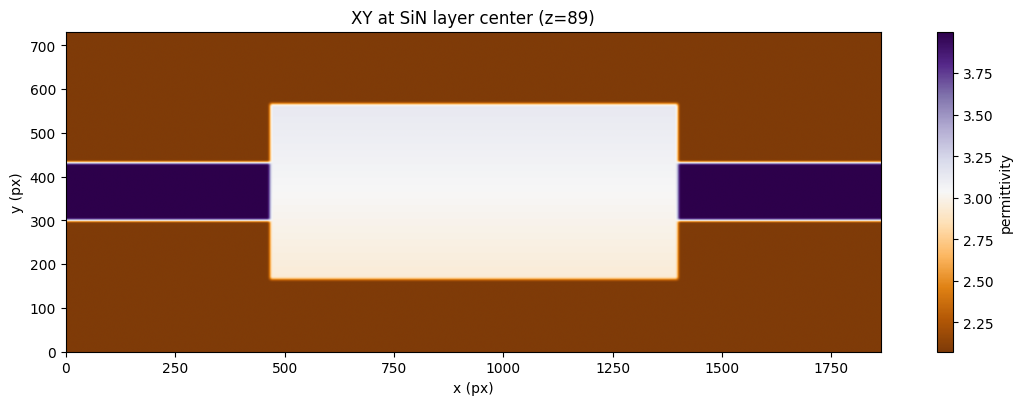

In [6]:
# Apply density filter
density = hwc.density(jnp.array(theta), radius=density_radius, alpha=0.0, eta=0.5)

# Define layer stack (no 3D materialization yet)
d_clad = jnp.zeros((nx, ny))
layers = [
    hwc.Layer(d_clad, eps_sio2, clad_px),
    hwc.Layer(density, (eps_sio2, eps_sin), wg_px),
    hwc.Layer(d_clad, eps_sio2, clad_px),
]

# Visualize XY slice at waveguide center (memory-efficient, no full 3D)
hwc.plot_structure_slice(layers, axis='xy', position=z_mid,
    title=f'XY at SiN layer center (z={z_mid})', figsize=(12, 4))
# Send to 3D viewer (standalone UI only)
hwc.show_device_3d(np.array(density), [
    {'name': 'box', 'thickness': clad_um, 'index': n_sio2, 'material': 'sio2'},
    {'name': 'sin', 'thickness': wg_height_um, 'index': n_sin, 'material': 'sin', 'is_design': True},
    {'name': 'clad', 'thickness': clad_um, 'index': n_sio2, 'material': 'sio2'},
], pixel_size)

## Step 6: XZ Cross-Section (Layer Stack)

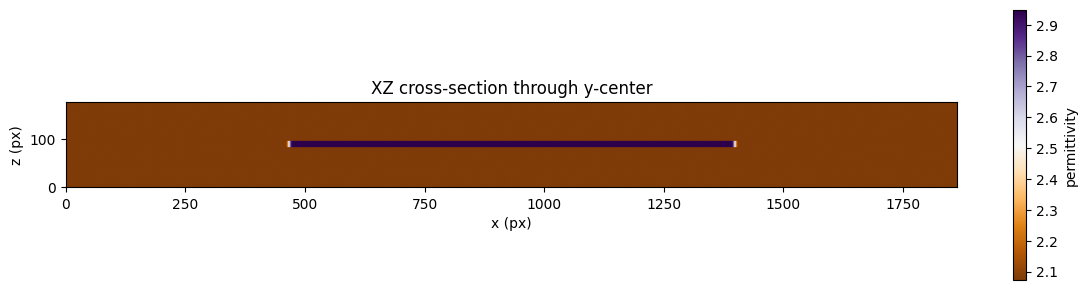

In [7]:
# XZ cross-section through y-center (memory-efficient)
Ly_half = ny // 4  # y-center in perm coords
hwc.plot_structure_slice(layers, axis='xz', position=Ly_half,
    title='XZ cross-section through y-center', figsize=(12, 3))

## Step 7: Absorbing Boundaries

Absorber (flat): widths=(55, 27, 27), coeff=0.000274


Perm grid: 932 x 366 x 179 = 61,059,048 cells
Absorber: widths=(55, 27, 27), coeff=0.000274


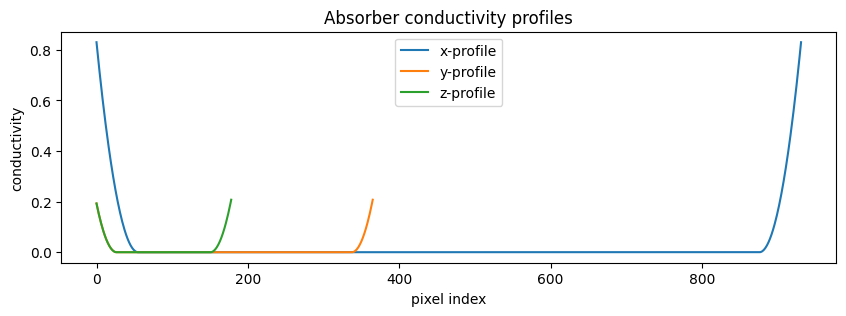

In [8]:
# Compute grid dimensions from layers (without materializing 3D)
Lx_s = nx // 2
Ly_s = ny // 2
Lz_s = sum(l.layer_thickness for l in layers)

abs_params = hwc.absorber_params(
    wavelength_um=wavelength,
    dx_um=voxel_size,
    structure_dimensions=(Lx_s, Ly_s, Lz_s),
    device_type='flat',
)
abs_widths = abs_params['absorption_widths']
absorption_coeff = abs_params['abs_coeff']
print(f'Perm grid: {Lx_s} x {Ly_s} x {Lz_s} = {Lx_s*Ly_s*Lz_s:,} cells')
print(f'Absorber: widths={abs_widths}, coeff={absorption_coeff:.6f}')

# Absorber profile
abs_arr = np.array(hwc.create_absorption_mask(
    grid_shape=(Lx_s, Ly_s, Lz_s),
    absorption_widths=abs_widths,
    absorption_coeff=absorption_coeff,
))
if abs_arr.ndim == 4:
    abs_arr = abs_arr[0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(abs_arr[:, Ly_s//2, Lz_s//2], label='x-profile')
ax.plot(abs_arr[Lx_s//2, :, Lz_s//2], label='y-profile')
ax.plot(abs_arr[Lx_s//2, Ly_s//2, :], label='z-profile')
ax.set_title('Absorber conductivity profiles')
ax.set_xlabel('pixel index')
ax.set_ylabel('conductivity')
ax.legend()
plt.show()

## Step 8: TE0 Mode Source

Solve for the fundamental TE0 mode of the 2um SiN input waveguide and create the source field. This is computed locally (no GPU needed).

Structure: 932 x 366 x 179 = 61,059,048 cells
Auto-detected waveguide at y=183 (width=65), using perpendicular_bounds=(53, 313)
Auto-detected z_core=89, using z_bounds=(0, 179)
Source: shape=(1, 6, 1, 260, 179), offset=(60, 53, 0), beta=[0.20706393]


TE0 n_eff = 1.7027
Source field shape: (1, 6, 1, 260, 179)
Source offset: (60, 53, 0)


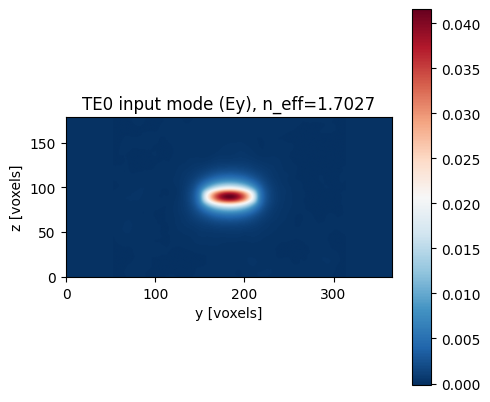

In [9]:
# Build full 3D structure (needed for mode solver)
structure = hwc.create_structure(layers=layers, vertical_radius=2)
absorber = hwc.create_absorption_mask(
    grid_shape=(Lx_s, Ly_s, Lz_s),
    absorption_widths=abs_widths,
    absorption_coeff=absorption_coeff,
)
structure.conductivity = jnp.zeros_like(structure.conductivity) + absorber

wl_px = wavelength / voxel_size
omega = float(2 * np.pi / wl_px)
freq_band = (omega, omega, 1)

source_field, source_offset, mode_info = hwc.create_mode_source(
    structure=structure,
    freq_band=freq_band,
    mode_num=0,
    propagation_axis='x',
    source_position=abs_widths[0] + 5,
)
n_eff_in = float(mode_info['beta'][0]) / (2 * np.pi / wl_px)
print(f'TE0 n_eff = {n_eff_in:.4f}')
print(f'Source field shape: {source_field.shape}')
print(f'Source offset: {source_offset}')

# Visualize input mode profile
ey_mode = np.array(mode_info['field'][0, 1, 0, :, :])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.real(ey_mode).T, origin='lower', cmap='RdBu_r')
ax.set_title(f'TE0 input mode (Ey), n_eff={n_eff_in:.4f}')
ax.set_xlabel('y [voxels]')
ax.set_ylabel('z [voxels]')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Step 9: Target TE1 Mode

Solve for the TE1 mode of the output waveguide. The optimizer will maximize the overlap between the output field and this target mode.

TE1 n_eff = 1.5694
Mode field shape: (1, 6, 1, 80, 80)
Padded to full monitor: (1, 6, 1, 366, 179)


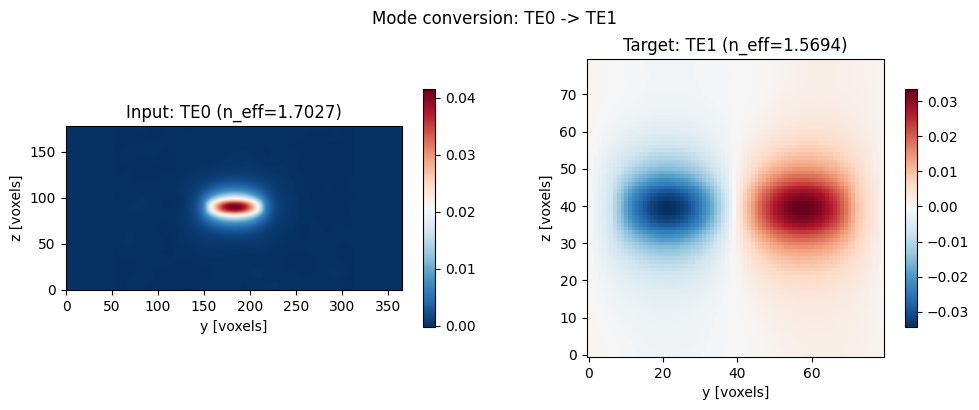

In [10]:
# Solve TE1 mode of output waveguide (mode_number=2: TE0=0, TM0=1, TE1=2)
mode_te1_field, n_eff_te1 = hwc.solve_waveguide_mode(
    grid=voxel_size,
    waveguide_width=wg_width_um,
    waveguide_height=wg_height_um,
    n_core=n_sin,
    n_clad=n_sio2,
    wavelength=wavelength,
    mode_number=2,
    cross_section_size=80,
)
print(f'TE1 n_eff = {n_eff_te1:.4f}')
print(f'Mode field shape: {mode_te1_field.shape}')

# Pad mode field to full output monitor size
mode_te1_full = np.zeros((1, 6, 1, Ly_s, Lz_s), dtype=np.complex64)
_, _, _, my, mz = mode_te1_field.shape
y0 = (Ly_s - my) // 2
z0 = (Lz_s - mz) // 2
mode_te1_full[:, :, :, y0:y0+my, z0:z0+mz] = mode_te1_field
print(f'Padded to full monitor: {mode_te1_full.shape}')

# Visualize target mode - should show two-lobe pattern
ey_te1 = np.real(mode_te1_field[0, 1, 0, :, :])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# TE0 input
im0 = axes[0].imshow(np.real(ey_mode).T, origin='lower', cmap='RdBu_r')
axes[0].set_title(f'Input: TE0 (n_eff={n_eff_in:.4f})')
axes[0].set_xlabel('y [voxels]')
axes[0].set_ylabel('z [voxels]')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# TE1 target
im1 = axes[1].imshow(ey_te1.T, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'Target: TE1 (n_eff={n_eff_te1:.4f})')
axes[1].set_xlabel('y [voxels]')
axes[1].set_ylabel('z [voxels]')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle('Mode conversion: TE0 -> TE1')
plt.tight_layout()
plt.show()

## Step 10: Monitors

Monitor added: Input_te0 (shape=(1, 366, 179), offset=(70, 0, 0))
Monitor added: Output_te1 (shape=(1, 366, 179), offset=(867, 0, 0))
Monitor added: xy_mid (shape=(932, 366, 1), offset=(0, 0, 89))


Input monitor at x=70
Output monitor at x=867


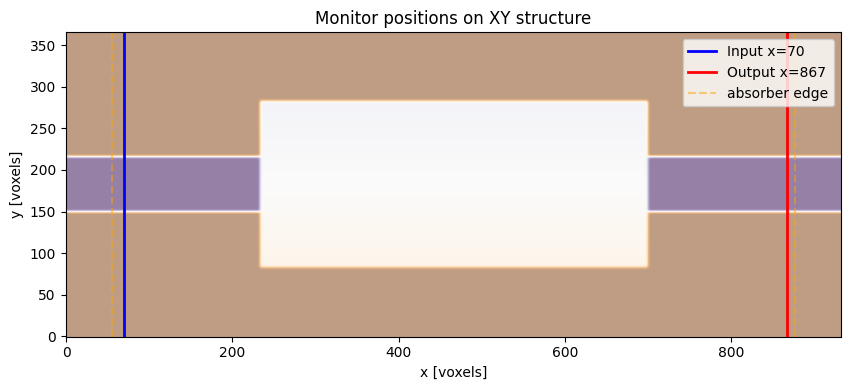

In [11]:
monitors = hwc.MonitorSet()

# Input monitor (just past source, for P_in normalization)
in_mon_x = abs_widths[0] + 15
monitors.add(hwc.Monitor(shape=(1, Ly_s, Lz_s), offset=(in_mon_x, 0, 0)), name='Input_te0')

# Output monitor (before right absorber)
out_mon_x = Lx_s - abs_widths[0] - 10
monitors.add(hwc.Monitor(shape=(1, Ly_s, Lz_s), offset=(out_mon_x, 0, 0)), name='Output_te1')

# XY visualization plane at waveguide center
monitors.add(hwc.Monitor(shape=(Lx_s, Ly_s, 1), offset=(0, 0, z_mid)), name='xy_mid')

print(f'Input monitor at x={in_mon_x}')
print(f'Output monitor at x={out_mon_x}')

# Visualize monitor positions on structure
eps_xy = np.array(structure.permittivity[0, :, :, z_mid])
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(eps_xy.T, origin='lower', cmap='PuOr', alpha=0.5)
ax.axvline(in_mon_x, color='blue', ls='-', lw=2, label=f'Input x={in_mon_x}')
ax.axvline(out_mon_x, color='red', ls='-', lw=2, label=f'Output x={out_mon_x}')
ax.axvline(abs_widths[0], color='orange', ls='--', alpha=0.5, label='absorber edge')
ax.axvline(Lx_s - abs_widths[0], color='orange', ls='--', alpha=0.5)
ax.set_title('Monitor positions on XY structure')
ax.set_xlabel('x [voxels]')
ax.set_ylabel('y [voxels]')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
# Update 3D viewer with monitor positions
hwc.show_device_3d(np.array(density), [
    {'name': 'box', 'thickness': clad_um, 'index': n_sio2, 'material': 'sio2'},
    {'name': 'sin', 'thickness': wg_height_um, 'index': n_sin, 'material': 'sin', 'is_design': True},
    {'name': 'clad', 'thickness': clad_um, 'index': n_sio2, 'material': 'sio2'},
], pixel_size, monitors=[
    {'name': 'Input_te0', 'x': in_mon_x * voxel_size, 'y': Ly_s * voxel_size / 2, 'width': Ly_s * voxel_size * 0.6},
    {'name': 'Output_te1', 'x': out_mon_x * voxel_size, 'y': Ly_s * voxel_size / 2, 'width': Ly_s * voxel_size * 0.6},
])

## Step 11: Forward Simulation

Run a forward FDTD simulation to verify the setup and measure the baseline performance before optimization.

In [14]:
# API key is configured via the Environment panel (or call hwc.configure_api(api_key='...'))
hwc.configure_api(api_key="1ae9b020-c6ce-445f-a3b7-c7971239e806", validate=False)


results = hwc.simulate(
    structure_recipe=structure.extract_recipe(),
    source_field=source_field,
    source_offset=source_offset,
    freq_band=freq_band,
    monitors_recipe=monitors.recipe,
    mode_info=mode_info,
    simulation_steps=15000,
    absorption_widths=abs_widths,
    absorption_coeff=absorption_coeff,
    gpu_type='B200',
)
print(f'Sim time: {results["sim_time"]:.1f}s')
print(f'Converged: {results["converged"]}')

# Compute TE1 mode overlap at output monitor
out_field = np.array(results['monitor_data']['Output_te1'])  # (1, 6, 1, Ly, Lz)
out_2d = out_field[0, :, 0, :, :]  # (6, Ly, Lz)

# Pad mode_te1_field to match output monitor size
mode_2d = np.zeros((6, Ly_s, Lz_s), dtype=np.complex64)
_, _, _, my, mz = mode_te1_field.shape
y0 = (Ly_s - my) // 2
z0 = (Lz_s - mz) // 2
mode_2d[:, y0:y0+my, z0:z0+mz] = mode_te1_field[0, :, 0, :, :]

# Mode overlap: |Re(integral(E_mode x H_sim* + E_sim x H_mode*))| / (2 * P_in * P_mode)
E_sim, H_sim = out_2d[:3], out_2d[3:]
E_mode, H_mode = mode_2d[:3], mode_2d[3:]
I1 = np.sum(np.cross(E_mode, np.conj(H_sim), axis=0)[0])  # x-component of Poynting
I2 = np.sum(np.cross(E_sim, np.conj(H_mode), axis=0)[0])

# Input power from Poynting flux at input monitor
in_field = np.array(results['monitor_data']['Input_te0'])
in_2d = in_field[0, :, 0, :, :]
S_in = np.real(np.cross(in_2d[:3], np.conj(in_2d[3:]), axis=0)[0])
P_in = np.abs(np.sum(S_in))

T_te1 = float(np.abs(np.real(I1 * I2)) / (2 * P_in))
print(f'\nBaseline (unoptimized):')
print(f'  P_in: {P_in:.4e}')
print(f'  T_TE1: {T_te1*100:.2f}% ({10*np.log10(max(T_te1, 1e-10)):.1f} dB)')


Local workflow: preparing simulation data for cloud GPU

Encoding source field...

Starting GPU simulation...
  GPU: B200, Max steps: 15000
  Convergence: default
Calling /early_stopping API...
Simulation completed in 18.3s (total: 52.0s)
  Converged at step 6000


Sim time: 18.3s
Converged: True

Baseline (unoptimized):
  P_in: 1.4265e-01
  T_TE1: 0.20% (-27.0 dB)


## Step 12: Visualize Forward Fields

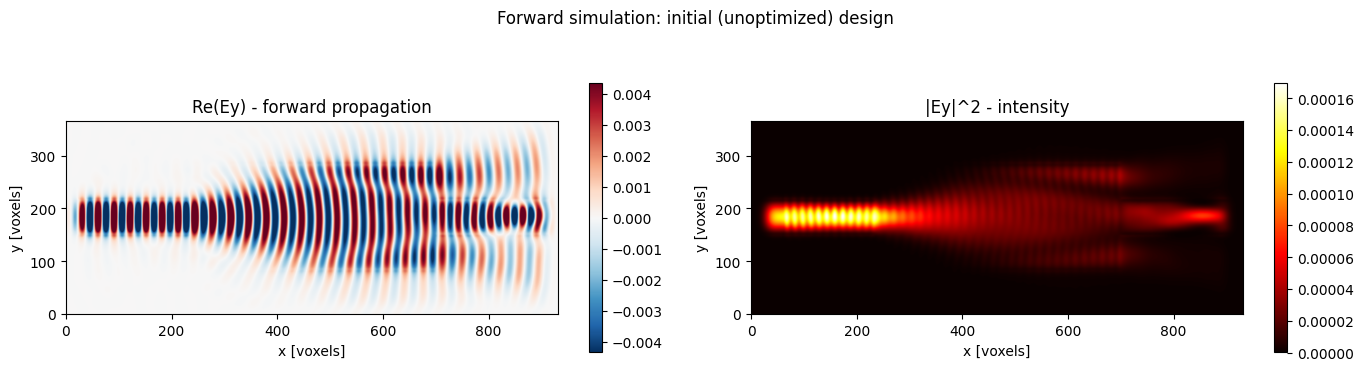

In [15]:
# XY field at waveguide center
if 'xy_mid' in results['monitor_data']:
    xy_field = np.array(results['monitor_data']['xy_mid'])
    ey_fwd = xy_field[0, 1, :, :, 0]  # Ey

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    vmax = np.max(np.abs(ey_fwd)) / 3

    im0 = axes[0].imshow(np.real(ey_fwd).T, origin='lower', cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax)
    axes[0].set_title('Re(Ey) - forward propagation')
    axes[0].set_xlabel('x [voxels]')
    axes[0].set_ylabel('y [voxels]')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow((np.abs(ey_fwd)**2).T, origin='lower', cmap='hot')
    axes[1].set_title('|Ey|^2 - intensity')
    axes[1].set_xlabel('x [voxels]')
    axes[1].set_ylabel('y [voxels]')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.suptitle('Forward simulation: initial (unoptimized) design')
    plt.tight_layout()
    plt.show()
else:
    print('No xy_mid monitor data available')

## Step 13: Optimization Objective

Maximize TE1 mode coupling at the output port. The `hwc.objectives` module defines loss functions as safe expression trees (no code execution on the server).

In [16]:
objective = hwc.objectives.mode_coupling(
    mode_field=mode_te1_full,
    input_power=1.0,
    mode_cross_power=1.0,
    monitor='Output_te1',
)
print(f'Objective: {objective}')

Objective: Objective(mode_coupling(monitor="Output_te1"))


## Step 14: Full Optimization Pipeline

The complete fabrication-aware pipeline:

| Phase | Steps | Description |
|-------|-------|-------------|
| Freeform | 0-99 | Topology optimization, LR=0.05 |
| Binarization 1 | 100-169 | beta=8 projection, LR=0.01 |
| Binarization 2 | 170-239 | beta=16 projection |
| Binarization 3 + fab | 240-339 | beta=32 + foundry penalty |
| Surgery + recovery | 340-359 | Remove small features, recover performance |

**Total: 360 steps, ~9.5 hours on B200.** Below we load pre-computed results.

In [17]:
ref = np.load('data/mc_reference_run.npz', allow_pickle=True)
eff_history = ref['efficiency_history']
phase_ends = ref['phase_ends']  # [100, 170, 240, 340, 360]
print(f'Loaded {len(eff_history)}-step optimization trajectory')
# Tanh-Heaviside projection (same as the optimization pipeline)
def project_density(theta, radius, beta, eta=0.5):
    """Filter + tanh-Heaviside projection."""
    u = np.array(hwc.density(jnp.array(theta), radius=radius, alpha=0.0))  # filter only
    if beta == 0:
        return u
    num = np.tanh(beta * eta) + np.tanh(beta * (u - eta))
    den = np.tanh(beta * eta) + np.tanh(beta * (1 - eta))
    return num / den


Loaded 360-step optimization trajectory


## Step 15: Phase 1 - Freeform Optimization (100 steps)

100 steps of adjoint topology optimization with Adam (LR=0.05). No binarization or fabrication constraints yet. The optimizer freely explores the design space.

In [20]:
mc_layers = [
    {'name': 'box', 'thickness': clad_um, 'index': n_sio2},
    {'name': 'sin', 'thickness': wg_height_um, 'index': n_sin,
     'design': True, 'density_radius': density_radius},
    {'name': 'clad', 'thickness': clad_um, 'index': n_sio2},
]

# Phase 1: Freeform (uncomment to run, ~2h on B200)
result_freeform = hwc.optimize(
    layers=mc_layers,
    theta={'sin': theta},
    grid=voxel_size,
    wavelength=wavelength,
    source=source_field,
    mode=mode_te1_full,
    phase='freeform',
    n_steps=3,
    learning_rate=0.05,
)

# eff_freeform = eff_history[:100]
# density_init = project_density(ref['theta_step000'], density_radius, beta=0)
# density_100 = project_density(ref['theta_step100'], density_radius, beta=0)

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# axes[0].plot(eff_freeform * 100, 'b-', lw=1.5)
# axes[0].set_xlabel('Step')
# axes[0].set_ylabel('Efficiency (%)')
# axes[0].set_title(f'Phase 1: {eff_freeform[-1]*100:.1f}%')
# axes[0].grid(True, alpha=0.3)

# im1 = axes[1].imshow(density_init.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
# axes[1].set_title('Initial density')
# axes[1].set_xlabel('x [density px]')
# plt.colorbar(im1, ax=axes[1], shrink=0.8)

# im2 = axes[2].imshow(density_100.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
# axes[2].set_title('After freeform (step 100)')
# axes[2].set_xlabel('x [density px]')
# plt.colorbar(im2, ax=axes[2], shrink=0.8)

# plt.tight_layout()
# plt.show()
# print(f'Phase 1: {eff_freeform[-1]*100:.2f}% ({10*np.log10(eff_freeform[-1]):.2f} dB)')

# from IPython.display import Image, display
# display(Image(filename='data/mc_phase1.gif'))

Structure: 932 x 366 x 179 = 61,059,048 cells
Starting pipeline optimize (phase=freeform, n_steps=3)...
  Session started in 1.7s: e24a6268...


RuntimeError: Invalid or missing session_id

## Step 16: Phase 2 - Binarization (240 steps)

Three epochs of increasing projection sharpness drive theta toward binary (0 or 1):
- Epoch 1: beta=8, 70 steps (steps 100-169)
- Epoch 2: beta=16, 70 steps (steps 170-239)
- Epoch 3: beta=32, 100 steps (steps 240-339)

LR drops to 0.01. The projection sharpens the density filter output, forcing features to commit to material or void.

Density: (1864, 732)
Density: (1864, 732)


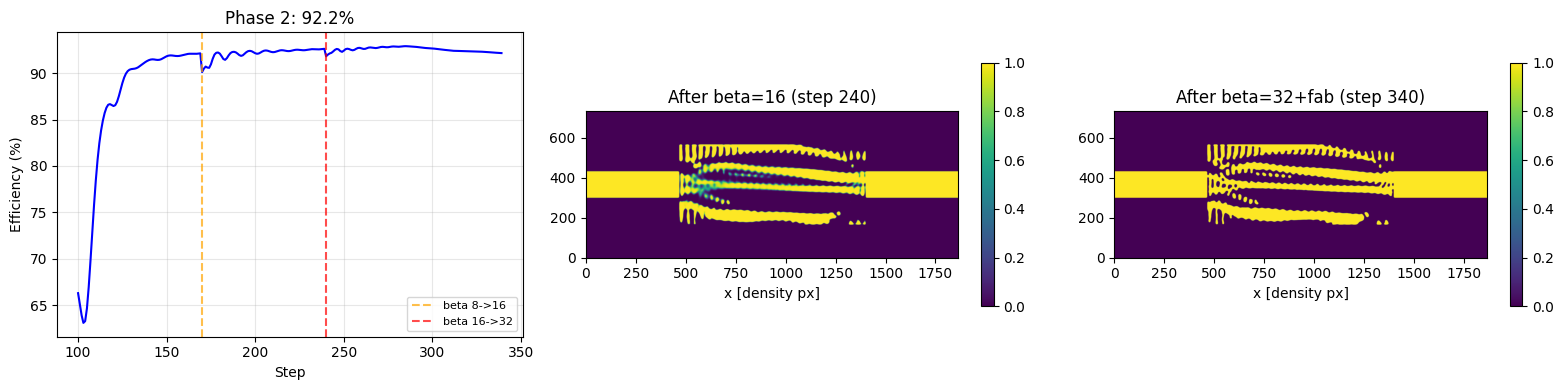

Phase 2: 92.17% (-0.35 dB)


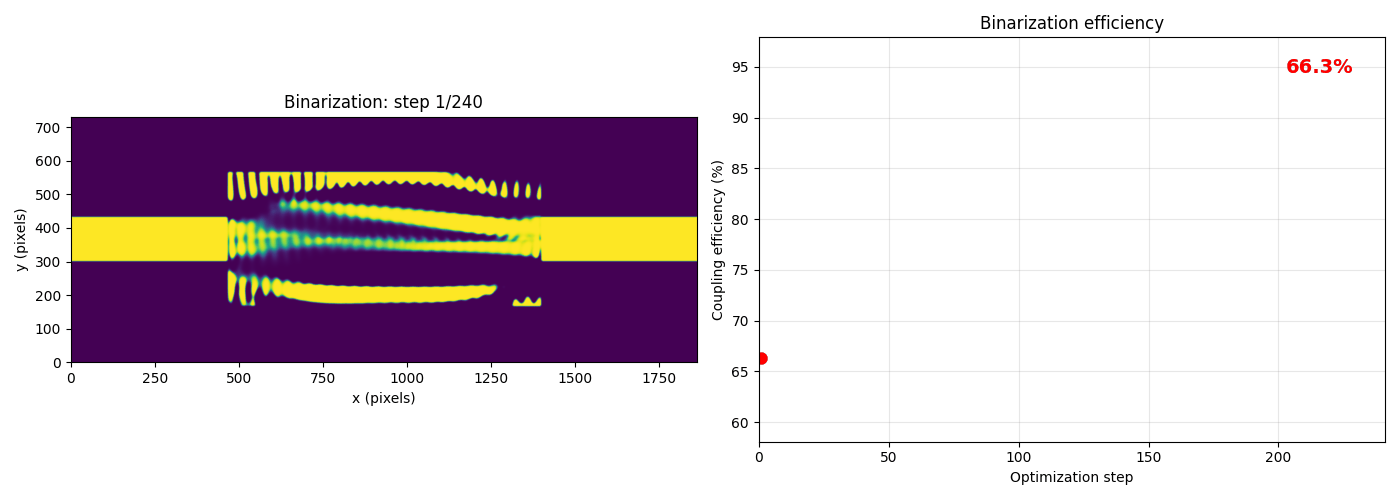

In [86]:
# Phase 2: Binarization - 3 epochs with increasing projection sharpness
# Each epoch is a fresh optimizer start (hard restart)
#
# result_b8 = hwc.optimize(
#     layers=mc_layers,
#     theta=result_freeform.design.thetas,
#     grid=voxel_size, wavelength=wavelength,
#     source=source_field, mode=mode_te1_full,
#     initial_design=result_freeform.design,
#     phase='binarize', n_steps=70,
#     beta_init=8, beta_max=8, learning_rate=0.01,
# )
#
# result_b16 = hwc.optimize(
#     ..., initial_design=result_b8.design,
#     beta_init=16, beta_max=16, n_steps=70,
# )
#
# result_b32 = hwc.optimize(
#     ..., initial_design=result_b16.design,
#     beta_init=32, beta_max=32, n_steps=100,
# )

eff_binarize = eff_history[100:340]
density_240 = project_density(ref['theta_step240'], density_radius, beta=16)
density_340 = project_density(ref['theta_step340'], density_radius, beta=32)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(range(100, 340), eff_binarize * 100, 'b-', lw=1.5)
ax.axvline(170, color='orange', ls='--', alpha=0.7, label='beta 8->16')
ax.axvline(240, color='red', ls='--', alpha=0.7, label='beta 16->32')
ax.set_xlabel('Step')
ax.set_ylabel('Efficiency (%)')
ax.set_title(f'Phase 2: {eff_binarize[-1]*100:.1f}%')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

im1 = axes[1].imshow(density_240.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('After beta=16 (step 240)')
axes[1].set_xlabel('x [density px]')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(density_340.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
axes[2].set_title('After beta=32+fab (step 340)')
axes[2].set_xlabel('x [density px]')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()
print(f'Phase 2: {eff_binarize[-1]*100:.2f}% ({10*np.log10(eff_binarize[-1]):.2f} dB)')

display(Image(filename='data/mc_phase2.gif'))

## Step 17: Phase 3 - Fabrication Constraints

The final binarization epoch (beta=32) includes a foundry-rule penalty from Hammond et al. that penalizes features violating minimum CD and gap rules. The penalty weight ramps from 0 to 100000 over the epoch, pushing the optimizer to resolve DRC violations while maintaining performance.

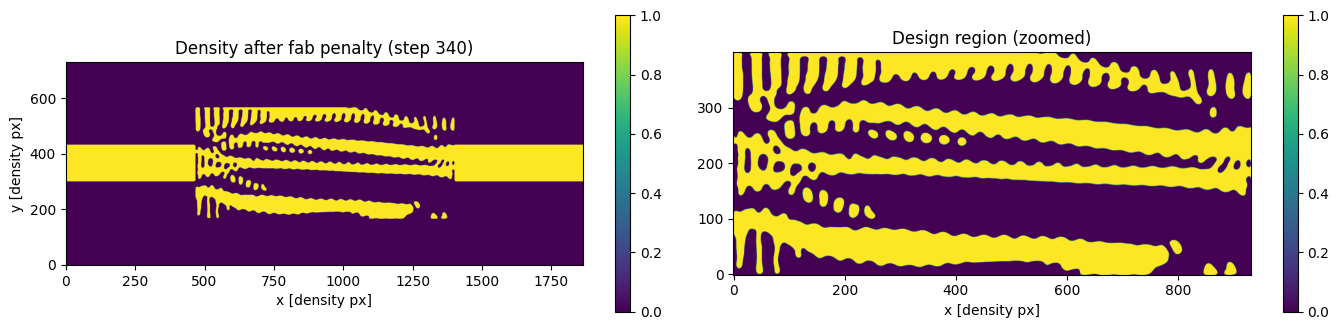

In [87]:
# The fab penalty was applied during epoch 3 (beta=32, steps 240-339)
# fab_weight ramped: 1e-15 -> 100000 over 100 steps

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im0 = axes[0].imshow(density_340.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Density after fab penalty (step 340)')
axes[0].set_xlabel('x [density px]')
axes[0].set_ylabel('y [density px]')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Zoom into design region
dr = density_340[dx0t:dx1t, dy0t:dy1t]
im1 = axes[1].imshow(dr.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('Design region (zoomed)')
axes[1].set_xlabel('x [density px]')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## Step 17b: Min-Area Check Before Surgery

After binarization + fab penalty, we check for residual small features. The foundry-rule penalty targets CD and gap at the pixel level, but small islands and interior holes (< 30,000nm^2) can still remain. Surgery removes them, then 20 recovery steps restore performance.

Density: (1864, 732)
Density: (1864, 732)
Density: (1864, 732)


Removed 2 islands, filled 6 holes


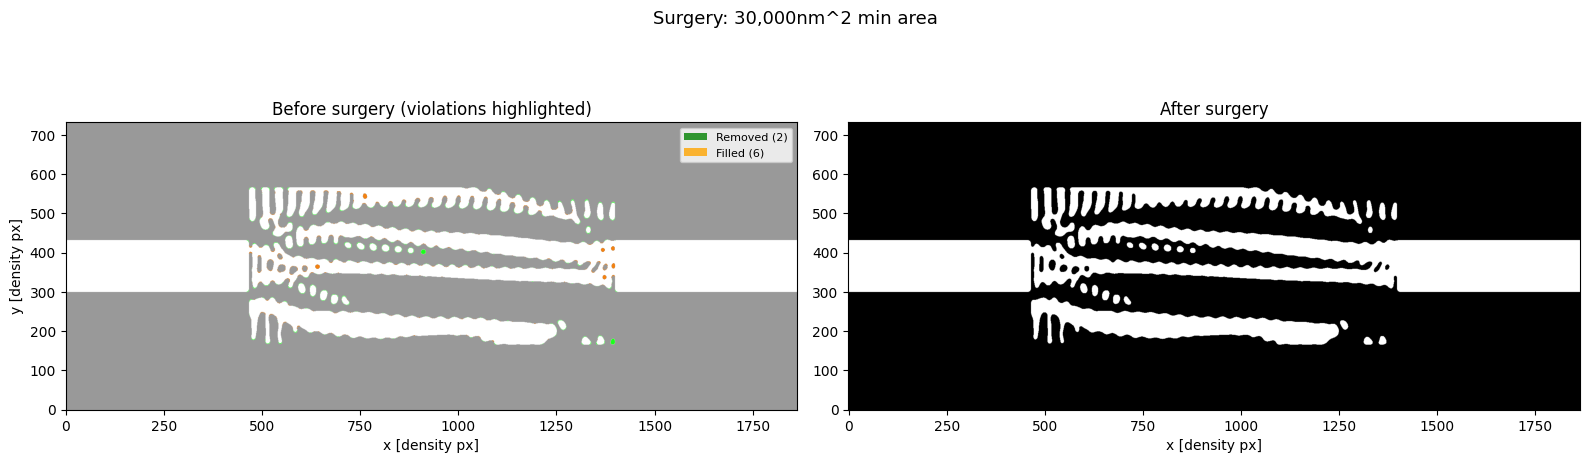

In [88]:
from scipy.ndimage import label as scipy_label

design_pre = hwc.Design(
    thetas={'sin': ref['theta_step339']},
    density_radii={'sin': density_radius},
    efficiency=float(eff_history[339]),
)

design_post = hwc.surgery(
    design=design_pre,
    min_area_nm2=30_000,
    pixel_size=pixel_size,
)
print(f'Removed {design_post.removed_islands} islands, filled {design_post.filled_holes} holes')

# Show what surgery found and fixed
d_pre = np.array(hwc.density(jnp.array(design_pre.thetas['sin']), radius=density_radius))
d_post = np.array(hwc.density(jnp.array(design_post.thetas['sin']), radius=density_radius))
b_pre = (d_pre >= 0.5)
removed = b_pre & ~(d_post >= 0.5)   # was solid, now void = removed islands
filled = ~b_pre & (d_post >= 0.5)     # was void, now solid = filled holes

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before: density with violations highlighted
axes[0].imshow(b_pre.astype(float).T, origin='lower', cmap='gray', alpha=0.4)
ov_r = np.zeros((*b_pre.shape, 4))
ov_r[..., 1] = 1.0
ov_r[..., 3] = removed.astype(float) * 0.9
ov_f = np.zeros((*b_pre.shape, 4))
ov_f[..., 0] = 1.0
ov_f[..., 1] = 0.5
ov_f[..., 3] = filled.astype(float) * 0.9
axes[0].imshow(ov_r.transpose(1, 0, 2), origin='lower')
axes[0].imshow(ov_f.transpose(1, 0, 2), origin='lower')
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, fc='green', alpha=0.8, label=f'Removed ({design_post.removed_islands})'),
    plt.Rectangle((0,0),1,1, fc='orange', alpha=0.8, label=f'Filled ({design_post.filled_holes})'),
], loc='upper right', fontsize=8)
axes[0].set_title('Before surgery (violations highlighted)')
axes[0].set_xlabel('x [density px]')
axes[0].set_ylabel('y [density px]')

# After: clean
axes[1].imshow((d_post >= 0.5).astype(float).T, origin='lower', cmap='gray')
axes[1].set_title('After surgery')
axes[1].set_xlabel('x [density px]')

plt.suptitle(f'Surgery: 30,000nm^2 min area', fontsize=13)
plt.tight_layout()
plt.show()

## Step 18: Phase 4 - Surgery and Recovery (20 steps)

After binarization, a DRC check identifies remaining violations (small features, narrow gaps). These are fixed by direct geometric surgery on theta, followed by 20 recovery optimization steps to regain any lost performance.

Density: (1864, 732)


Final: 92.00% (-0.36 dB)


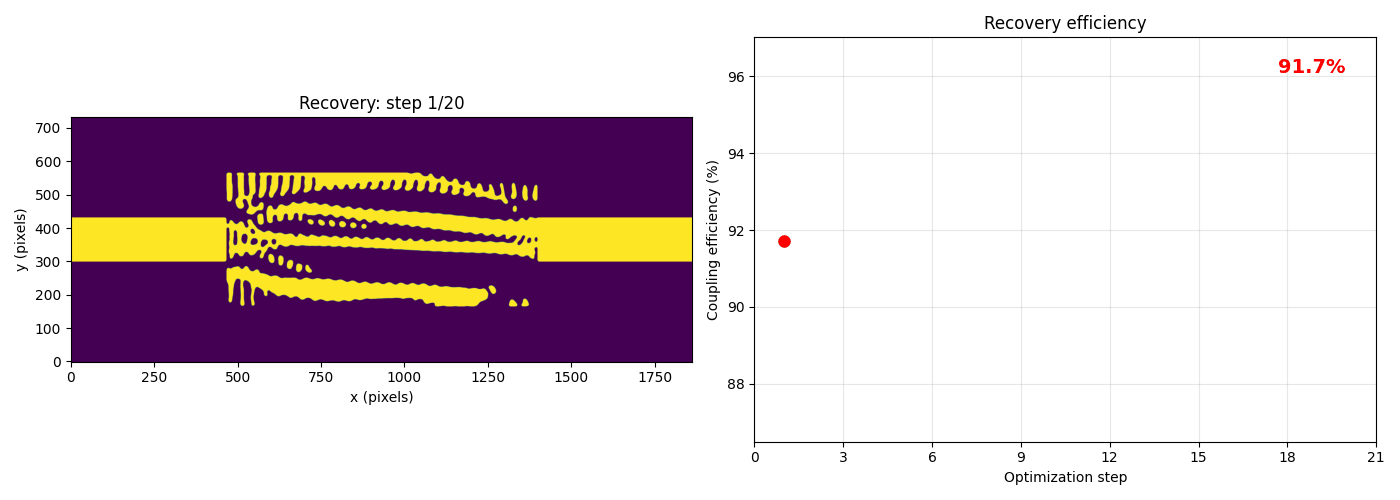

In [94]:
# Phase 4: Recovery after surgery (20 steps, fresh optimizer)
# result_recovery = hwc.optimize(
#     layers=mc_layers,
#     theta=design_post.thetas,
#     grid=voxel_size, wavelength=wavelength,
#     source=source_field, mode=mode_te1_full,
#     initial_design=design_post,
#     phase='recovery', n_steps=20,
#     beta_init=32, beta_max=32, learning_rate=0.01,
# )

theta_final = ref['theta_step359']
density_final = project_density(theta_final, density_radius, beta=32)
print(f'Final: {eff_history[359]*100:.2f}% ({10*np.log10(eff_history[359]):.2f} dB)')

from IPython.display import Image, display
display(Image(filename='data/mc_phase4.gif'))

## Step 19: Pipeline Summary

Phase                   Steps  Efficiency  Loss (dB)
Freeform                  100       90.4%       0.44
Binarize                  140       92.6%       0.33
Fab Constraints           100       92.2%       0.35
Recovery                   20       92.0%       0.36
-------------------------------------------------------
Total                     360 steps
Time:                  ~9.5 GPU-hours (~95s/step)


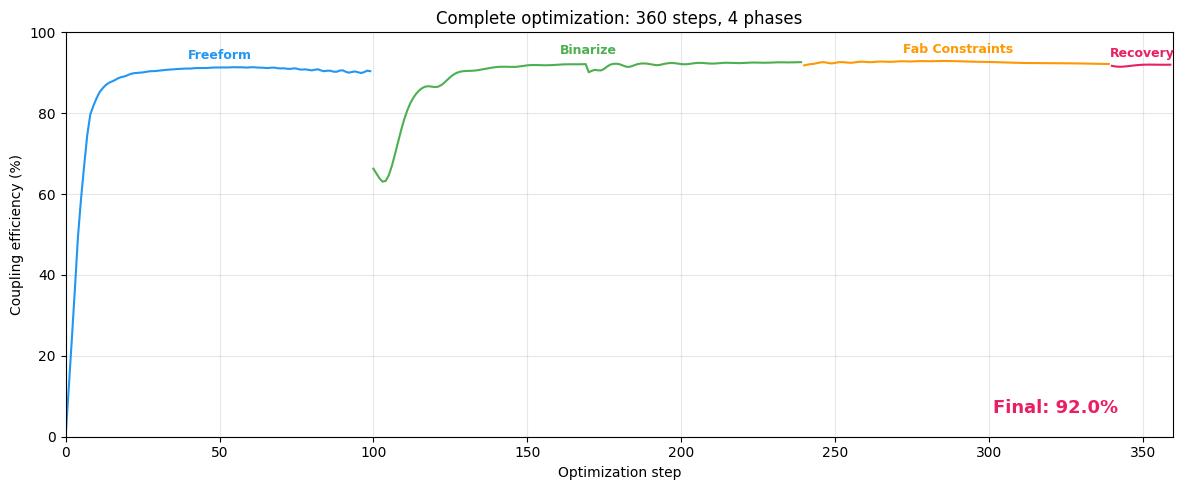

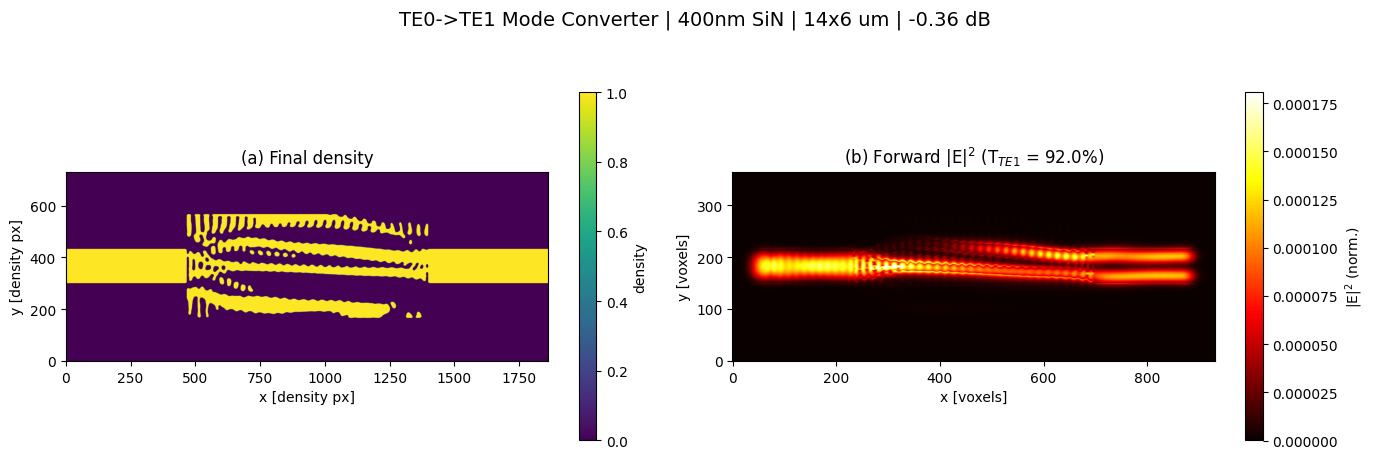

In [90]:
# Pipeline summary
phase_info = [
    ('Freeform',          0, 100, '#2196F3'),
    ('Binarize',        100, 240, '#4CAF50'),
    ('Fab Constraints', 240, 340, '#FF9800'),
    ('Recovery',        340, 360, '#E91E63'),
]
print(f'{"Phase":<22s} {"Steps":>6s} {"Efficiency":>11s} {"Loss (dB)":>10s}')
for name, s0, s1, _ in phase_info:
    eff = eff_history[s1-1]
    loss = -10 * np.log10(eff) if eff > 0 else float('inf')
    print(f'{name:<22s} {s1-s0:>6d} {eff*100:>10.1f}% {loss:>10.2f}')
print('-' * 55)
print(f'{"Total":<22s} {360:>6d} steps')
print(f'{"Time:":<22s} ~9.5 GPU-hours (~95s/step)')
# Convergence plot
fig, ax = plt.subplots(figsize=(12, 5))
for name, s0, s1, color in phase_info:
    ax.plot(range(s0, s1), eff_history[s0:s1] * 100, color=color, lw=1.5)
    mid = (s0 + s1) // 2
    ax.text(mid, max(eff_history[s0:s1]) * 100 + 2, name,
            ha='center', fontsize=9, color=color, fontweight='bold')
ax.text(0.95, 0.05, f'Final: {eff_history[-1]*100:.1f}%',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=13, color='#E91E63', fontweight='bold')
ax.set_xlim(0, 360)
ax.set_ylim(0, 100)
ax.set_xlabel('Optimization step')
ax.set_ylabel('Coupling efficiency (%)')
ax.set_title('Complete optimization: 360 steps, 4 phases')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Final results (matching paper Fig. 1)
ref = np.load('data/mc_reference_run.npz', allow_pickle=True)
E2_xy = ref['E2_xy']
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes2[0].imshow(density_final.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
axes2[0].set_title('(a) Final density')
axes2[0].set_xlabel('x [density px]')
axes2[0].set_ylabel('y [density px]')
plt.colorbar(im0, ax=axes2[0], shrink=0.8, label='density')
vmax_e = np.max(E2_xy) * 0.8
im1 = axes2[1].imshow(E2_xy.T, origin='lower', cmap='hot', vmax=vmax_e)
axes2[1].set_title(f'(b) Forward |E|$^2$ (T$_{{TE1}}$ = {eff_history[-1]*100:.1f}%)')
axes2[1].set_xlabel('x [voxels]')
axes2[1].set_ylabel('y [voxels]')
plt.colorbar(im1, ax=axes2[1], shrink=0.8, label='|E|$^2$ (norm.)')
plt.suptitle('TE0->TE1 Mode Converter | 400nm SiN | 14x6 um | -0.36 dB', fontsize=14)
plt.tight_layout()
plt.show()

## Step 20: DRC Verification

Check the final design for minimum CD and gap violations using morphological opening. At 15nm/px with disk(r=4): minimum feature = (2*4+1) * 15nm = 135nm, exceeding the 120nm spec.

In [91]:
# Final DRC on the recovered design
design_final = hwc.Design(
    thetas={'sin': theta_final},
    density_radii={'sin': density_radius},
)

drc_report = hwc.check_drc(
    design=design_final,
    disk_radius=4,
    pixel_size=pixel_size,
)

print(f'CD violations:  {drc_report.cd_pct:.2f}%')
print(f'Gap violations: {drc_report.gap_pct:.2f}%')
print(f'Min feature:    {drc_report.min_feature_nm:.0f}nm')
print(f'Status:         {drc_report.status}')

Density: (1864, 732)


CD violations:  0.03%
Gap violations: 0.04%
Min feature:    135nm
Status:         PASS (< 1% violations)


## Step 21: GDS Export

In [92]:
density_final = project_density(theta_final, density_radius, beta=32)

gds_path = hwc.generate_gds_from_density(
    density_array=density_final,
    level=0.5,
    output_filename='mode_converter.gds',
    resolution=pixel_size,
)
print(f'GDS saved to: {gds_path}')
print(f'Design size: {theta_final.shape[0] * pixel_size:.1f} x {theta_final.shape[1] * pixel_size:.1f} um')

Density: (1864, 732)


GDS saved to: /home/jimqu/projects/github/spins/hyperwave/notebooks/mode_converter.gds
Design size: 28.0 x 11.0 um


## Step 22: Visualize GDS Layout

117 GDS polygons


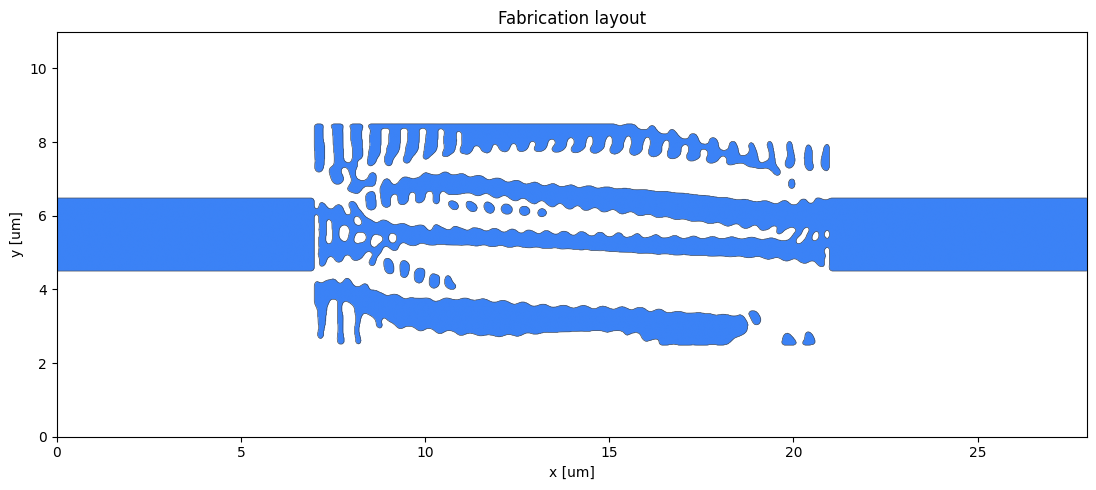

In [93]:
import gdstk
from matplotlib.colors import ListedColormap

lib = gdstk.read_gds(gds_path)
cell_gds = lib.top_level()[0]
polygons = cell_gds.get_polygons()
print(f'{len(polygons)} GDS polygons')

x_um = density_final.shape[0] * pixel_size
y_um = density_final.shape[1] * pixel_size

# Toggle: 'gds' shows exact polygon seams, 'clean' shows seamless binary density
mode = 'clean'  # change to 'gds' for polygon view

fig, ax = plt.subplots(figsize=(14, 5))

if mode == 'gds':
    for poly in polygons:
        pts = poly.points[:, ::-1]
        patch = plt.Polygon(pts, edgecolor='white', facecolor='#3B82F6', lw=0.3)
        ax.add_patch(patch)
    ax.set_xlim(0, x_um)
    ax.set_ylim(0, y_um)
    ax.set_facecolor('white')
    x_ax = np.linspace(0, x_um, density_final.shape[0])
    y_ax = np.linspace(0, y_um, density_final.shape[1])
    ax.contour(x_ax, y_ax, density_final.T, levels=[0.5],
               colors=['#333333'], linewidths=0.4)
    ax.set_title(f'GDS layout ({len(polygons)} polygons)')
else:
    cmap = ListedColormap(['white', '#3B82F6'])
    ax.imshow((density_final >= 0.5).astype(float).T, origin='lower',
              cmap=cmap, vmin=0, vmax=1, extent=[0, x_um, 0, y_um],
              interpolation='antialiased')
    x_ax = np.linspace(0, x_um, density_final.shape[0])
    y_ax = np.linspace(0, y_um, density_final.shape[1])
    ax.contour(x_ax, y_ax, density_final.T, levels=[0.5],
               colors=['#333333'], linewidths=0.4)
    ax.set_title('Fabrication layout')

ax.set_xlabel('x [um]')
ax.set_ylabel('y [um]')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()